In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from imutils import paths
import matplotlib.pyplot as plt
import numpy as np
import argparse
import os

In [2]:
#ap = argparse.ArgumentParser()
#ap.add_argument("-d", "-dataset", required=True,
	#help="path to input dataset")
#ap.add_argument("-p", "-plot", type=str, default="plot.png",
	#help="path to output loss/accuracy plot")
#ap.add_argument("-m", "-model", type=str,
	#default="mask_detectorch.model",
	#help="path to output face mask detector model")
#args = vars(ap.parse_args())

In [3]:
BS=32
INIT_LR=1e-4
EPOCHS=20

In [4]:
args = {
    "dataset": "data/",
    "plot": "plot.png",
    "model": "mask_detectorch.model"
}
# read dataset images from data
# save the output grapy with this name plot.png
# save the model with this name mask_detectorch.model

In [5]:
print('[INFO] loading images...')
imagepaths=list(paths.list_images(r"E:\DS\Deep learning\face mask detection\dataset"))
data=[]
labels=[]
for imagepath in imagepaths:
    label=imagepath.split(os.path.sep)[-2]
    labels.append(label)
    image = load_img(imagepath, target_size = (224,224),color_mode="rgb")
    # load_img is preprocessing tool Load the image file & Resizes it to (224, 224)_
    image = img_to_array(image)
    # img_to_array is preprocessing tool & Convert image into numbers
    image = preprocess_input(image)
    # preprocess_input is normalizing the value into specific range 
    data.append(image)

[INFO] loading images...


C:\Users\Public\anaconda\Lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [6]:
# Explaination
# coding - imagepaths = list(paths.list_images(args['dataset'])) Explaination - This collects all image file paths from your dataset folder.
# coding - data = [] labels = [] Explaination - data → will store images  labels → will store names (cats, dogs, etc.)
# coding - for imagePath in imagepaths Explaination - Take one image path at a time
# coding -  label=imagepaths.split(os.path.sep)[-2] Explaination - os.path.sep is the system-specific character used to separate folders in a file path.
# [-2] means take the second last item from the list 
# imagePath = "dataset/cat/img1.jpg"
# imagePath.split(os.path.sep)
# ['dataset', 'cat', 'img1.jpg']
# ['dataset', 'cat', 'img1.jpg'][-2] 
# 'cat'

In [7]:
# other option of resizing the image 
# Keras - image = load_img(path, target_size=(224,224))
# OpenCV -  import cv2, image = cv2.imread(path), image = cv2.resize(image, (224, 224))
# PIL (Pillow) - from PIL import Image, image = Image.open(path), image = image.resize((224, 224))
# TensorFlow method - image = tf.image.resize(image, (224, 224))

In [8]:
# converr the data and labels to numpy array
data = np.array(data,dtype='float32')
labels = np.array(labels)
labels

array(['without_mask', 'without_mask', 'without_mask', ..., 'with_mask',
       'with_mask', 'with_mask'], shape=(3846,), dtype='<U12')

In [9]:
# performing one hot encoding on the labels 
# labelencoder directly convert the string into one hot encoding 
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
labels = le.fit_transform(labels)
labels = to_categorical(labels)
labels

array([[0., 1.],
       [0., 1.],
       [0., 1.],
       ...,
       [1., 0.],
       [1., 0.],
       [1., 0.]], shape=(3846, 2))

In [10]:
x_train,x_test,y_train,y_test=train_test_split(data,labels,test_size=0.20,random_state=42)

In [11]:
# Construct the training image generate for data augmentation(modifying the original image)
aug=ImageDataGenerator(rotation_range=20,zoom_range=0.15,width_shift_range=0.2,height_shift_range=0.2,
                       shear_range=0.15,horizontal_flip=True,fill_mode='nearest')

In [12]:
# Load the MobileNetV2 network ensuring the head FC layer set are left off 
baseModel=MobileNetV2(weights='imagenet',include_top=False,input_tensor=Input(shape=(224,224,3)))

C:\Users\ROHINI S\AppData\Local\Temp\ipykernel_13844\3775239685.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  baseModel=MobileNetV2(weights='imagenet',include_top=False,input_tensor=Input(shape=(224,224,3)))


In [13]:
# Construct the heas of the model that will be placed on top of the base model.
headmodel=baseModel.output
headmodel=AveragePooling2D(pool_size=(7,7))(headmodel)
headmodel=Flatten(name='flatten')(headmodel)
headmodel=Dense(128,activation='relu')(headmodel)
headmodel=Dropout(0.5)(headmodel)
headmodel=Dense(2,activation='softmax')(headmodel)

In [14]:
# Place the head FC model on top of the base model (this will became the actual model we will train)
model=Model(inputs=baseModel.input,outputs=headmodel)

In [15]:
for layer in baseModel.layers:
    layer.trainable=False

In [16]:
#complie our model
print('[INFO]compiling model...')
opt= Adam(learning_rate=INIT_LR,decay=INIT_LR/EPOCHS) 
model.compile(loss='binary_crossentropy',optimizer=opt,metrics=['accuracy'])

[INFO]compiling model...


C:\Users\Public\anaconda\Lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [17]:
print('[INFO] training head...')
h=model.fit(
  aug.flow(x_train,y_train,batch_size=BS), 
  steps_per_epoch=len(x_train)//BS,
  validation_steps=len(x_test)//BS,
  validation_data=(x_test, y_test),
  epochs=EPOCHS)

[INFO] training head...


C:\Users\Public\anaconda\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 63s 599ms/step - accuracy: 0.8410 - loss: 0.4190 - val_accuracy: 0.9675 - val_loss: 0.1593
Epoch 2/20
 1/96 ━━━━━━━━━━━━━━━━━━━━ 27s 287ms/step - accuracy: 0.9375 - loss: 0.1881

C:\Users\Public\anaconda\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.9375 - loss: 0.1881 - val_accuracy: 0.9688 - val_loss: 0.1575
Epoch 3/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 55s 577ms/step - accuracy: 0.9632 - loss: 0.1527 - val_accuracy: 0.9727 - val_loss: 0.0941
Epoch 4/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - accuracy: 0.9375 - loss: 0.1506 - val_accuracy: 0.9714 - val_loss: 0.0934
Epoch 5/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 55s 575ms/step - accuracy: 0.9691 - loss: 0.1064 - val_accuracy: 0.9727 - val_loss: 0.0766
Epoch 6/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.9688 - loss: 0.0969 - val_accuracy: 0.9727 - val_loss: 0.0774
Epoch 7/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 55s 577ms/step - accuracy: 0.9754 - loss: 0.0813 - val_accuracy: 0.9766 - val_loss: 0.0640
Epoch 8/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.9375 - loss: 0.2356 - val_accuracy: 0.9766 - val_loss: 0.0640
Epoch 9/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 56s 584ms/step - accuracy: 0.9800 - loss: 0.0706 - val_accuracy: 0.9766 - va

In [18]:
# Make predictions on the testing set 
print("[INFO] evalvating network...")
predidcs=model.predict(x_test,batch_size=BS)
# batch_size tells predict() how many samples to process at one time.

[INFO] evalvating network...
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 344ms/step


In [19]:
# For each image in the testing set we need to find the index of the label with correspoonding largest predict probability
predidcs=np.argmax(predidcs,axis=1)
# label is in array so converting array into classes 

In [20]:
# show a nicely formatted classification report 
print(classification_report (y_test.argmax(axis=1),predidcs,target_names=le.classes_))

              precision    recall  f1-score   support

   with_mask       0.98      0.99      0.98       366
without_mask       0.99      0.98      0.99       404

    accuracy                           0.98       770
   macro avg       0.98      0.98      0.98       770
weighted avg       0.98      0.98      0.98       770



In [21]:
# Serialize the model to disk
print('[INFO] saving mask detector model...')
model.save("model.h5")

[INFO] saving mask detector model...


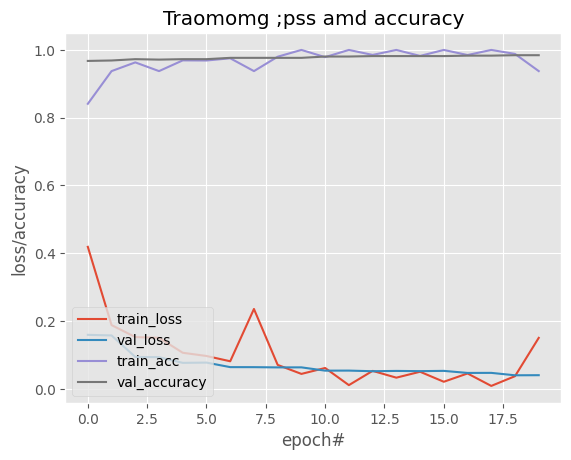

In [22]:
# Plot the training loss and accuracy
n=EPOCHS
plt.style.use('ggplot')
plt.figure()
plt.plot(np.arange(0,n),h.history['loss'],label='train_loss')
plt.plot(np.arange(0,n),h.history['val_loss'],label='val_loss')
plt.plot(np.arange(0,n),h.history['accuracy'],label='train_acc')
plt.plot(np.arange(0,n),h.history['val_accuracy'],label='val_accuracy')
plt.title('Traomomg ;pss amd accuracy')
plt.xlabel('epoch#')
plt.ylabel('loss/accuracy')
plt.legend(loc='lower left')
plt.savefig(args['plot'])